In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
competencias = "clean_competencias_23032026.csv"

In [14]:
df_competencias = pd.read_csv(competencias)

In [15]:
df_competencias

,Competencias,Año,Total empresas (sin filtrar),Empresa de entre 250 y 499 trabajadores,Empresa de servicios,Andalucía,Cataluña,Comunitat Valenciana,Comunidad de Madrid,País Vasco
0,Administrativas de oficina,2020,11.114247,10.057322,11.129611,12.561069,9.156032,9.432930,10.525672,17.405494
1,De atención al público/ trato a clientes,2020,18.633907,18.603439,23.863803,24.309160,18.531969,15.340667,17.595762,18.370955
2,De comunicación oral o escrita,2020,1.390927,3.387181,1.609155,0.557252,1.575984,0.510545,1.479218,2.760403
3,De cálculo o lingüísticas,2020,0.593872,1.354872,0.700746,0.431298,0.749675,0.237039,0.101874,0.598314
4,De dirección,2020,15.275113,23.032830,15.581089,18.022901,10.595409,16.981705,15.000000,13.530052
5,De resolución de problemas (localización de pr...,2020,11.671119,13.757165,12.245682,10.698473,13.973945,9.220203,16.320293,8.621159
6,De trabajo en equipo,2020,21.726806,22.928609,23.000220,22.610687,18.798521,19.005652,29.079055,23.551809
7,En lenguas extranjeras,2020,9.327614,29.963523,9.969628,5.496183,13.670743,7.943840,14.747351,10.946424
8,Generales de tecnologías de la información,2020,11.858625,22.355393,12.731448,13.190840,13.061007,9.894852,12.770986,10.742453
9,Otras,2020,16.351858,13.913497,16.999049,18.416031,21.507347,19.157600,11.454768,10.416100


In [16]:
df_competencias.describe().T

,count,mean,std,min,25%,50%,75%,max
Año,56.0,2021.964286,1.439246,2020.000000,2021.000000,2022.000000,2023.000000,2024.000000
Total empresas (sin filtrar),56.0,16.093520,11.937332,0.593872,8.720393,13.729734,19.750756,53.492995
Empresa de entre 250 y 499 trabajadores,56.0,20.642509,13.383820,1.354872,12.972945,18.478254,26.687616,62.793121
Empresa de servicios,56.0,16.576419,10.853855,0.700746,9.757640,13.856875,23.216115,47.535495
Andalucía,56.0,15.791279,11.324830,0.431298,5.926881,14.489920,21.082161,46.910078
Cataluña,56.0,16.578664,11.848238,0.749675,10.062901,14.054793,20.390992,53.993270
Comunitat Valenciana,56.0,15.762960,12.675106,0.237039,8.563136,13.368069,19.169292,54.099556
Comunidad de Madrid,56.0,17.285584,10.910244,0.101874,11.399256,15.239263,19.952393,55.647922
País Vasco,56.0,15.973740,12.866951,0.134862,8.981598,12.665551,18.164090,59.899374


In [17]:
df_competencias.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56 entries, 0 to 55
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Competencias                             56 non-null     object 
 1   Año                                      56 non-null     int64  
 2   Total empresas (sin filtrar)             56 non-null     float64
 3   Empresa de entre 250 y 499 trabajadores  56 non-null     float64
 4   Empresa de servicios                     56 non-null     float64
 5   Andalucía                                56 non-null     float64
 6   Cataluña                                 56 non-null     float64
 7   Comunitat Valenciana                     56 non-null     float64
 8   Comunidad de Madrid                      56 non-null     float64
 9   País Vasco                               56 non-null     float64
dtypes: float64(8), int64(1), object(1)
memory usage: 4.5

Análisis Univariante: El "Top" de Competencias en 2024 - ¿Qué competencias son las más demandadas globalmente?

C:\Users\rubit\AppData\Local\Temp\ipykernel_18340\4044328500.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_comp.head(10), x='Total empresas (sin filtrar)', y='Competencias', palette='viridis')


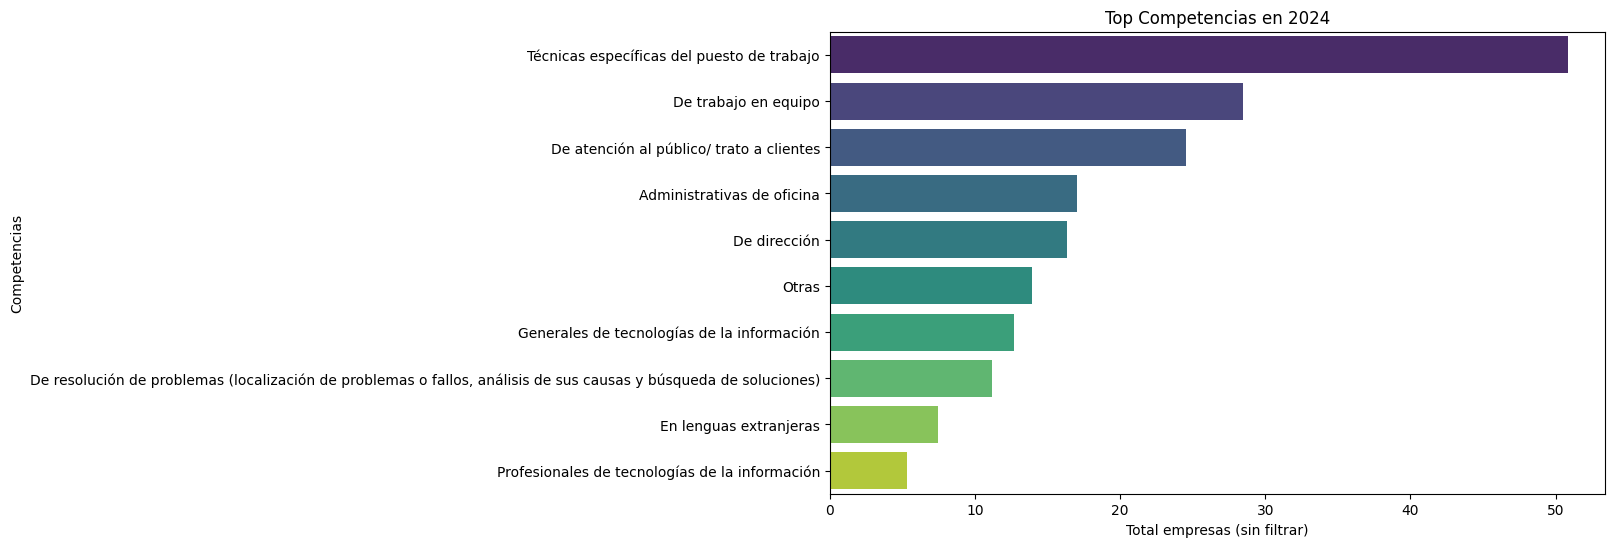

In [18]:
last_year = df_competencias['Año'].max()
top_comp = df_competencias[df_competencias['Año'] == last_year].sort_values(by='Total empresas (sin filtrar)', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_comp.head(10), x='Total empresas (sin filtrar)', y='Competencias', palette='viridis')
plt.title(f'Top Competencias en {last_year}')
plt.show()

Análisis de Tendencias (Serie Temporal)

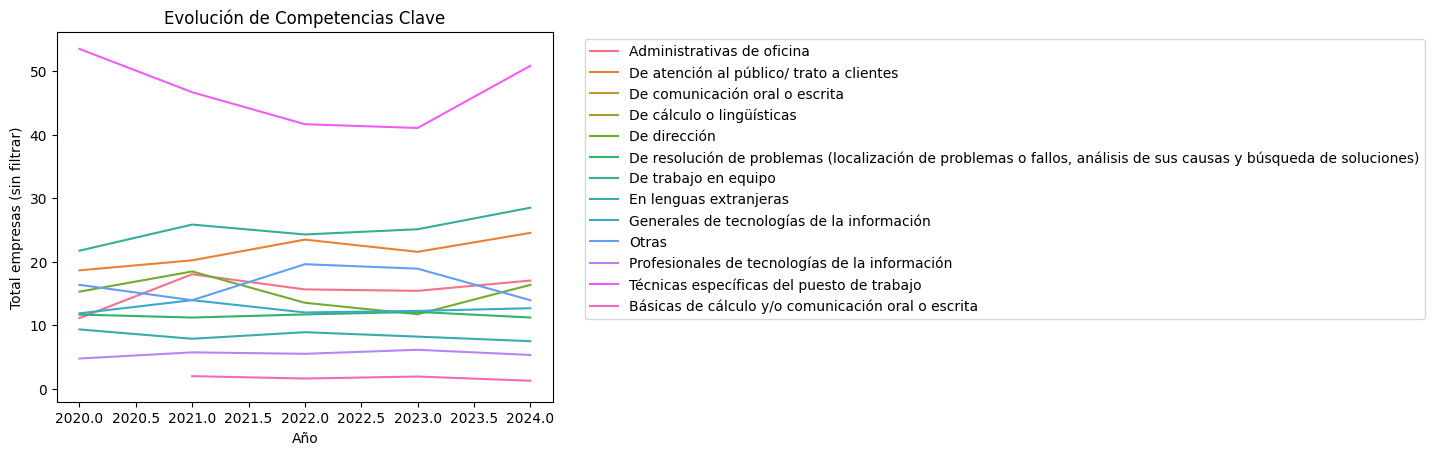

In [19]:

sns.lineplot(data=df_competencias, x='Año', y='Total empresas (sin filtrar)', hue='Competencias')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Evolución de Competencias Clave')
plt.show()

Análisis Segmentado (Regiones y Tamaño)

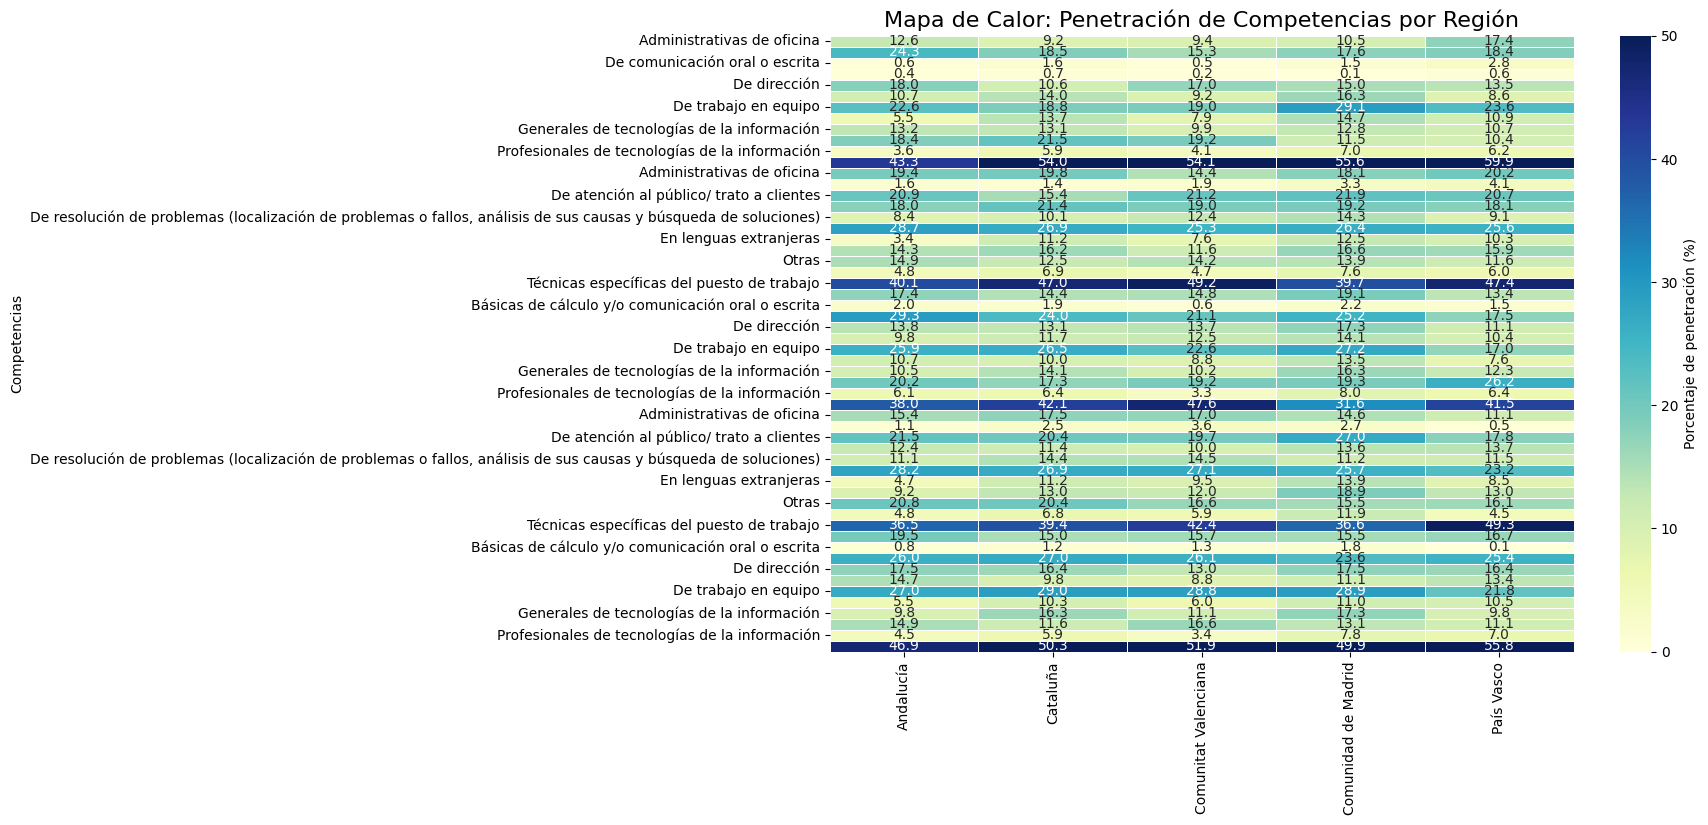

In [21]:
# Seleccionamos solo las columnas de regiones para el heatmap
regiones = ['Andalucía', 'Cataluña', 'Comunitat Valenciana', 'Comunidad de Madrid', 'País Vasco']
df_plot = df_competencias.set_index('Competencias')[regiones]

plt.figure(figsize=(12, 8))

# CONFIGURACIÓN CLAVE:
sns.heatmap(df_plot, 
            annot=True,       # Muestra el número dentro de la celda
            fmt=".1f",        # Un decimal para los porcentajes
            cmap="YlGnBu",    # Escala de Amarillo a Azul (muy profesional)
            vmin=0,           # El 0% es el punto de partida
            vmax=50,         # El 100% es el máximo teórico (ajusta a 50 si los valores son bajos)
            linewidths=.5,    # Separa las celdas para que se lea mejor
            cbar_kws={'label': 'Porcentaje de penetración (%)'})

plt.title('Mapa de Calor: Penetración de Competencias por Región', fontsize=16)
plt.show()

La competencia más potente es la de "Técnicas específicas del puesto de trabajo"

El gráfico de barras y la evolución temporal dejan claro que las "Técnicas específicas del puesto de trabajo" son la prioridad absoluta (más del 50% de penetración). 
**Interpretación:** No basta con formación genérica. El mercado exige especialización técnica dura (Hard Skills).
**Dato Clave:** Tras una caída entre 2020 y 2023, en 2024 ha pegado un rebote fuerte (vuelve a superar el 50%). La formación debe ser actualización técnica constante.

**TENDENCIAS**

Hay dos competencias que vienen "empujando" con una pendiente positiva constante:

**De trabajo en equipo:** Ha pasado de un 21% a casi un 30% en 4 años. Es la competencia soft más demandada.

**De atención al público / trato a clientes:** Mantiene un crecimiento sólido, consolidándose como la tercera más importante.

**Acción política:** La organización debería reforzar los módulos de colaboración híbrida/remota y experiencia de cliente.


**HEATMAP**

Vemos que el comportamiento es bastante homogéneo, pero hay "puntos calientes" interesantes:

País Vasco: Lidera con diferencia en Técnicas específicas (55.8%). Esto sugiere un entorno industrial o tecnológico muy especializado donde la formación técnica es crítica para sobrevivir.

Madrid y Cataluña: Son las que más "tiran" de las Generales de tecnologías de la información (~16-17%). Si vuestra organización está en estas regiones, la alfabetización digital básica ya no es opcional, es el estándar.

Andalucía: Muestra un interés notablemente alto en Resolución de problemas (14.7%) comparado con la media. Es una soft skill muy valorada allí.

-- **GRÁFICOS FINALES PARA EL ANÁLISIS** --


**TOP 10 COMPETENCIAS POR RELEVANCIA MEDIA (2020-2024)**

In [ ]:
#Definimos las columnas que queremos promediar (excluimos el Total General)
columnas_interes = [
    'Empresa de entre 250 y 499 trabajadores', 
    'Empresa de servicios', 
    'Andalucía', 'Cataluña', 'Comunitat Valenciana', 
    'Comunidad de Madrid', 'País Vasco'
]

C:\Users\rubit\AppData\Local\Temp\ipykernel_30060\3684852955.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




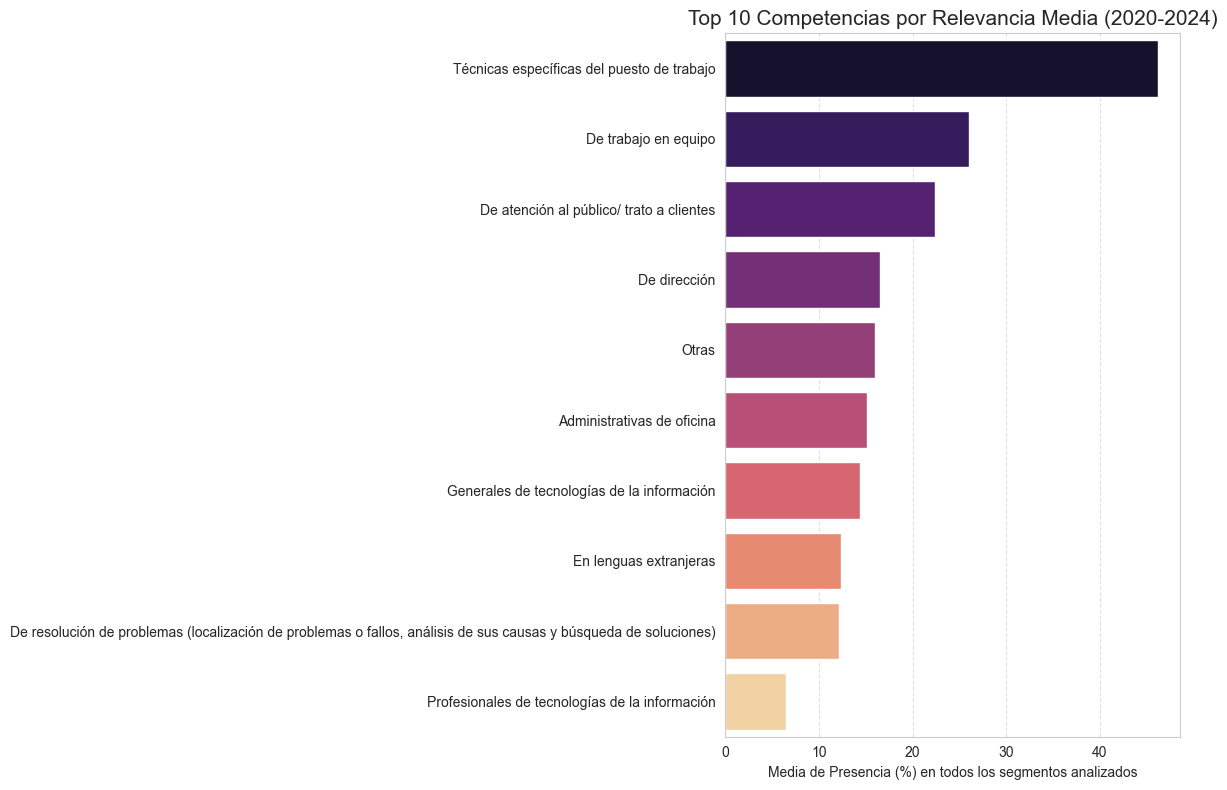

✅ Archivo 'top10_competencias_canva.csv' listo para descargar.


In [ ]:
# Agrupamos por Competencia y calculamos la media de todos los años
# Esto nos da el "peso" real de cada competencia en el periodo analizado
df_medias = df_competencias.groupby('Competencias')[columnas_interes].mean()

# 3. Creamos una columna 'Media Global' para poder hacer el Top 10
df_medias['Media_Global'] = df_medias.mean(axis=1)

# 4. Seleccionamos las 10 mejores
df_top10 = df_medias.sort_values('Media_Global', ascending=False).head(10)

# --- VISUALIZACIÓN EN PYTHON ---
plt.figure(figsize=(12, 8))
sns.barplot(
    x=df_top10['Media_Global'], 
    y=df_top10.index, 
    palette='magma'
)
plt.title('Top 10 Competencias por Relevancia Media (2020-2024)', fontsize=15)
plt.xlabel('Media de Presencia (%) en todos los segmentos analizados')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# --- EXPORTACIÓN PARA CANVA ---
# Para que Canva lo agrupe bien, exportamos el DataFrame con las columnas limpias
df_export_canva = df_top10.copy()

# Acortamos nombres de columnas para que el gráfico de Canva sea legible
df_export_canva.columns = [
    'Gran Empresa', 'Servicios', 'Andalucía', 
    'Cataluña', 'C. Valenciana', 'Madrid', 'País Vasco', 'Media Global'
]

df_export_canva.to_csv('top10_competencias_canva.csv', index_label='Competencia')
print("✅ Archivo 'top10_competencias_canva.csv' listo para descargar.")

**Evolución temporal de las 4 competencias líderes en el último año (Media de los segmentos)**

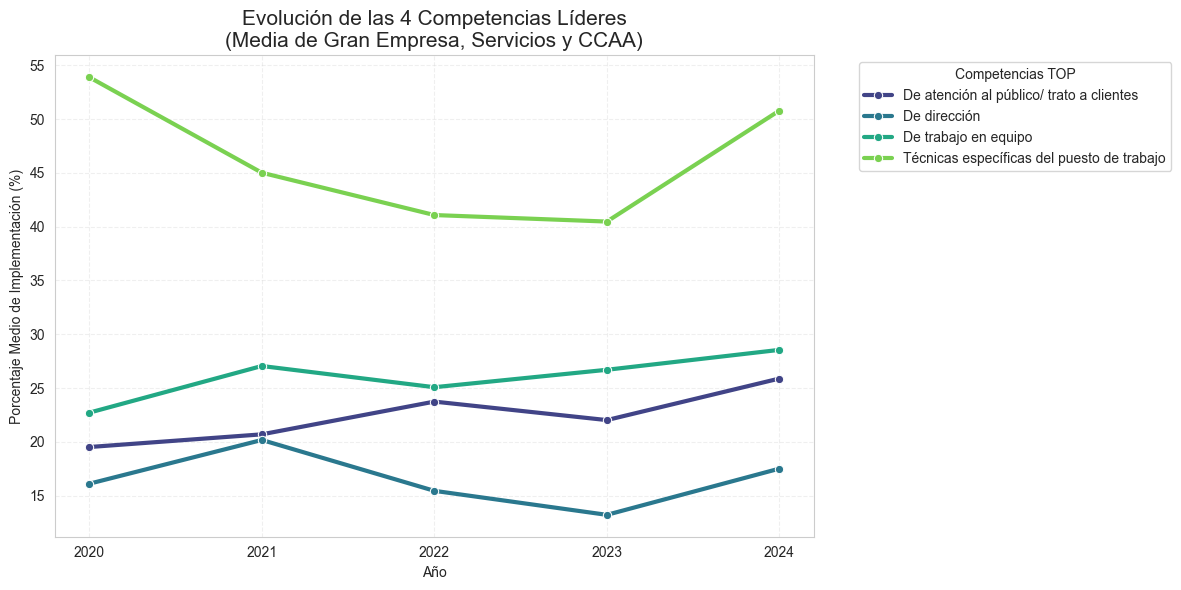

✅ Gráfico generado y archivo 'evolucion_top4_media_estudio.csv' creado para Canva.


In [ ]:
#Creamos una copia para no alterar el original y calculamos la media por fila
df_evol = df_competencias.copy()
df_evol['Media_Estudio'] = df_evol[columnas_interes].mean(axis=1)

#Identificamos las 4 competencias con mayor "Media_Estudio" en el último año (2024)
# (Esto asegura que graficamos las que son tendencia ahora)
top_4_nombres = (df_evol[df_evol['Año'] == 2024]
                 .sort_values('Media_Estudio', ascending=False)
                 .head(4)['Competencias'].tolist())

#Filtramos el dataframe para que solo contenga esas 4
df_plot = df_evol[df_evol['Competencias'].isin(top_4_nombres)]

# --- GRÁFICO DE EVOLUCIÓN ---
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_plot, x='Año', y='Media_Estudio', hue='Competencias', 
             marker='o', linewidth=3, palette='viridis')

plt.title('Evolución de las 4 Competencias Líderes\n(Media de Gran Empresa, Servicios y CCAA)', fontsize=15)
plt.ylabel('Porcentaje Medio de Implementación (%)')
plt.xlabel('Año')
plt.xticks([2020, 2021, 2022, 2023, 2024])
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Competencias TOP")

plt.tight_layout()
plt.show()

# --- EXPORTACIÓN PARA CANVA ---
# Creamos la tabla "Ancha" para que Canva agrupe bien por año
df_canva_evol = df_plot.pivot(index='Año', columns='Competencias', values='Media_Estudio')
df_canva_evol.to_csv('evolucion_top4_media_estudio.csv')

print("✅ Gráfico generado y archivo 'evolucion_top4_media_estudio.csv' creado para Canva.")

1. El Dominio de lo Técnico (La línea verde lima)
Las "Técnicas específicas del puesto de trabajo" son, con diferencia, la prioridad absoluta.

Análisis: Aunque tuvo una caída notable entre 2020 y 2023 (posiblemente porque durante la pandemia se priorizaron otros procesos de adaptación), en 2024 ha pegado un salto espectacular, volviendo a superar el 50%.

Conclusión: El sector ha vuelto a poner el foco en la "especialización". Para una empresa como Rapid Express, esto significa que no basta con formación general; el mercado exige que el trabajador sea experto en su tarea técnica concreta.

2. El Ascenso de las "Soft Skills" (Líneas verde oscuro y morada)
Aquí vemos una tendencia muy positiva para las competencias de Trabajo en Equipo y Atención al Cliente.

Análisis: Ambas líneas muestran una pendiente ascendente constante desde 2023. El Trabajo en Equipo ya roza el 30%, y la Atención al Cliente está en su punto más alto de los últimos 5 años (aprox. 26%).

Conclusión: El sector servicios está "humanizándose". Ya no solo importa que el paquete llegue (técnica), sino cómo colabora el equipo interno y cómo se trata al cliente final. Es una oportunidad de diferenciación competitiva.

3. La Crisis de la "Dirección" (Línea azul petróleo)
La competencia de "Dirección" es la única que ha tenido un comportamiento errático y a la baja hasta hace muy poco.

Análisis: Cayó con fuerza hasta 2023, situándose por debajo del 15%. Aunque en 2024 intenta recuperarse, sigue siendo la menos priorizada de las cuatro líderes.

Conclusión: Las empresas están invirtiendo mucho más en la "base" operativa (técnicos y atención) que en la formación de mandos intermedios o directivos.

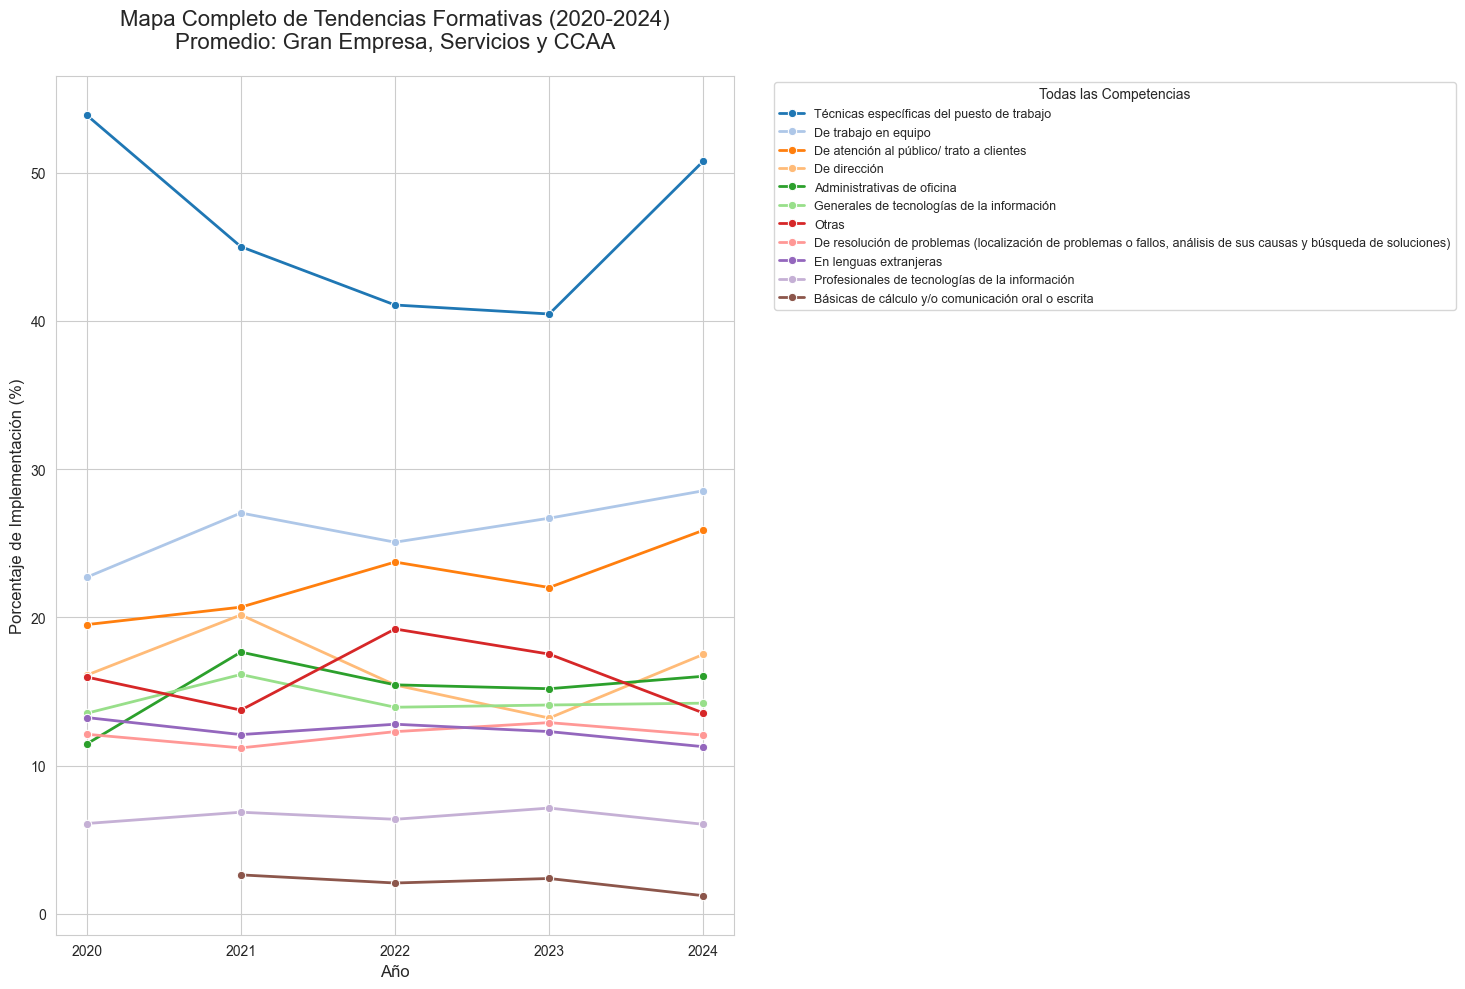

In [ ]:
#Calculamos la media por fila (por cada año y competencia)
df_total_evol = df_competencias.copy()
df_total_evol['Media_Estudio'] = df_total_evol[columnas_interes].mean(axis=1)

#Ordenamos las competencias por su valor en 2024 para que la leyenda sea legible
orden_leyenda = (df_total_evol[df_total_evol['Año'] == 2024]
                 .sort_values('Media_Estudio', ascending=False)['Competencias'].tolist())

# --- VISUALIZACIÓN EN PYTHON ---
plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")

# Graficamos todas las líneas
sns.lineplot(data=df_total_evol, x='Año', y='Media_Estudio', hue='Competencias', 
             hue_order=orden_leyenda, marker='o', linewidth=2, palette='tab20')

plt.title('Mapa Completo de Tendencias Formativas (2020-2024)\nPromedio: Gran Empresa, Servicios y CCAA', fontsize=16, pad=20)
plt.ylabel('Porcentaje de Implementación (%)', fontsize=12)
plt.xlabel('Año', fontsize=12)
plt.xticks([2020, 2021, 2022, 2023, 2024])

# Movemos la leyenda fuera para que no tape el gráfico, ya que habrá muchas líneas
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Todas las Competencias", fontsize=9)

plt.tight_layout()
plt.show()

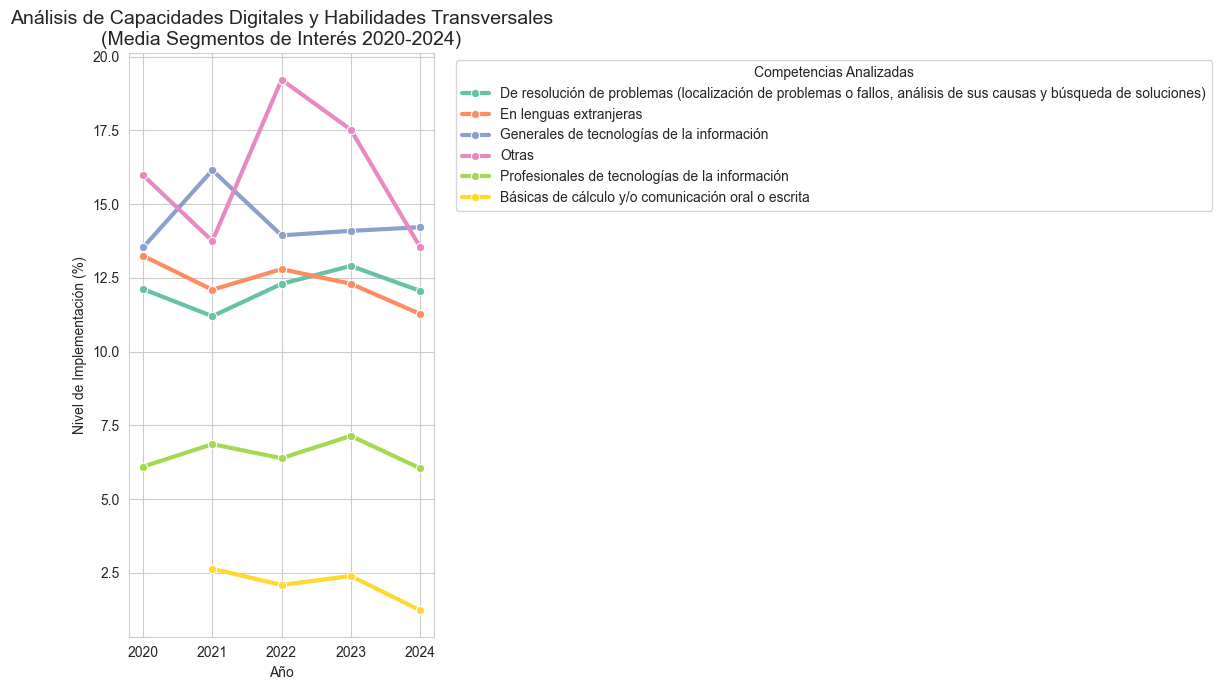

✅ Archivo 'analisis_nicho_estrategico_canva.csv' generado para subir a Canva.


In [ ]:
#Definimos la lista exacta de competencias de "Nicho Estratégico"
competencias_nicho = [
    'Generales de tecnologías de la información',
    'Profesionales de tecnologías de la información',
    'En lenguas extranjeras',
    'De resolución de problemas (localización de problemas o fallos, análisis de sus causas y búsqueda de soluciones)',
    'Básicas de cálculo y/o comunicación oral o escrita',
    'Otras'
]

# 2. Usamos la "Media de Estudio" que calculamos antes (Gran Empresa + Servicios + CCAA)
columnas_estudio = [
    'Empresa de entre 250 y 499 trabajadores', 
    'Empresa de servicios', 
    'Andalucía', 'Cataluña', 'Comunitat Valenciana', 
    'Comunidad de Madrid', 'País Vasco'
]

df_nicho = df_competencias[df_competencias['Competencias'].isin(competencias_nicho)].copy()
df_nicho['Media_Estudio'] = df_nicho[columnas_estudio].mean(axis=1)

# --- VISUALIZACIÓN EN PYTHON ---
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# Dibujamos las líneas
ax = sns.lineplot(data=df_nicho, x='Año', y='Media_Estudio', hue='Competencias', 
                 marker='o', linewidth=3, palette='Set2')

plt.title('Análisis de Capacidades Digitales y Habilidades Transversales\n(Media Segmentos de Interés 2020-2024)', fontsize=14)
plt.ylabel('Nivel de Implementación (%)')
plt.xticks([2020, 2021, 2022, 2023, 2024])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Competencias Analizadas")

plt.tight_layout()
plt.show()

# --- EXPORTACIÓN PARA CANVA ---
# Pivotamos para que Canva reconozca las líneas por columnas
df_canva_nicho = df_nicho.pivot(index='Año', columns='Competencias', values='Media_Estudio')

# Acortamos los nombres para que en Canva no se amontonen las etiquetas
df_canva_nicho.columns = [
    'Cálculo/Comunicación Básica',
    'Lenguas Extranjeras',
    'Resolución de Problemas',
    'TIC Generales (Office/Gestión)',
    'TIC Profesionales (Sistemas)',
    'Otras Formaciones'
]

df_canva_nicho.to_csv('analisis_nicho_estrategico_canva.csv')

print("✅ Archivo 'analisis_nicho_estrategico_canva.csv' generado para subir a Canva.")

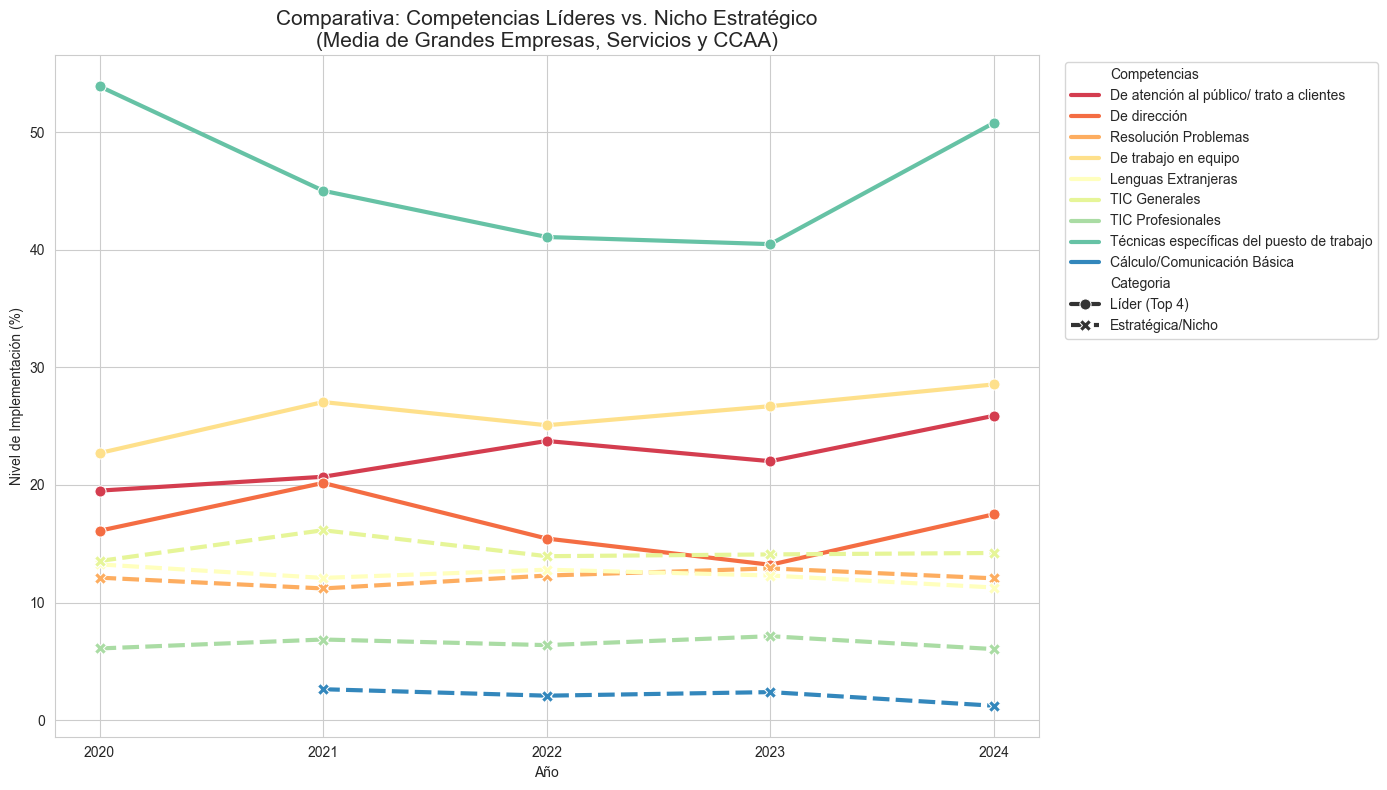

✅ Archivo 'comparativa_unificada_canva.csv' listo para descargar.


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. DEFINICIÓN DE COLUMNAS (Aquí estaba el error)
# Usamos las columnas que definiste para el análisis de segmentos
columnas_interes = [
    'Empresa de entre 250 y 499 trabajadores', 
    'Empresa de servicios', 
    'Andalucía', 'Cataluña', 'Comunitat Valenciana', 
    'Comunidad de Madrid', 'País Vasco'
]

# 2. PREPARACIÓN DE DATOS
df_union = df_competencias.copy()
# Calculamos la media basada en esas columnas
df_union['Media_Estudio'] = df_union[columnas_interes].mean(axis=1)

# Identificamos el Top 4 (Líderes) en el último año
top_4_nombres = (df_union[df_union['Año'] == 2024]
                 .sort_values('Media_Estudio', ascending=False)
                 .head(4)['Competencias'].tolist())

# Definimos las de Nicho/Transversales (con los nombres exactos de tu DF)
competencias_nicho = [
    'Generales de tecnologías de la información',
    'Profesionales de tecnologías de la información',
    'En lenguas extranjeras',
    'De resolución de problemas (localización de problemas o fallos, análisis de sus causas y búsqueda de soluciones)',
    'Básicas de cálculo y/o comunicación oral o escrita'
]

# 3. CATEGORIZACIÓN Y FILTRADO
def categorizar(nombre):
    if nombre in top_4_nombres: return 'Líder (Top 4)'
    if nombre in competencias_nicho: return 'Estratégica/Nicho'
    return 'Otras'

df_union['Categoria'] = df_union['Competencias'].apply(categorizar)
df_final = df_union[df_union['Categoria'] != 'Otras'].copy()

# Acortamos nombres para que el gráfico no sea un caos
nombres_cortos = {
    'De resolución de problemas (localización de problemas o fallos, análisis de sus causas y búsqueda de soluciones)': 'Resolución Problemas',
    'Básicas de cálculo y/o comunicación oral o escrita': 'Cálculo/Comunicación Básica',
    'Generales de tecnologías de la información': 'TIC Generales',
    'Profesionales de tecnologías de la información': 'TIC Profesionales',
    'En lenguas extranjeras': 'Lenguas Extranjeras'
}
df_final['Competencias'] = df_final['Competencias'].replace(nombres_cortos)

# 4. VISUALIZACIÓN
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# Dibujamos diferenciando por estilo de línea
ax = sns.lineplot(
    data=df_final, 
    x='Año', 
    y='Media_Estudio', 
    hue='Competencias', 
    style='Categoria', # Las líderes serán continuas, las de nicho discontinuas
    markers=True, 
    markersize=8,
    linewidth=3,
    palette='Spectral'
)

plt.title('Comparativa: Competencias Líderes vs. Nicho Estratégico\n(Media de Grandes Empresas, Servicios y CCAA)', fontsize=15)
plt.ylabel('Nivel de Implementación (%)')
plt.xlabel('Año')
plt.xticks([2020, 2021, 2022, 2023, 2024])

# Ajuste de la leyenda
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 5. EXPORTACIÓN PARA CANVA
df_canva = df_final.pivot(index='Año', columns='Competencias', values='Media_Estudio')
df_canva.to_csv('comparativa_unificada_canva.csv')

print("✅ Archivo 'comparativa_unificada_canva.csv' listo para descargar.")

**Competencias por región - 2024**

✅ Top 4 detectado para tus segmentos:
['Técnicas específicas del puesto de trabajo', 'De trabajo en equipo', 'De atención al público/ trato a clientes', 'De dirección']


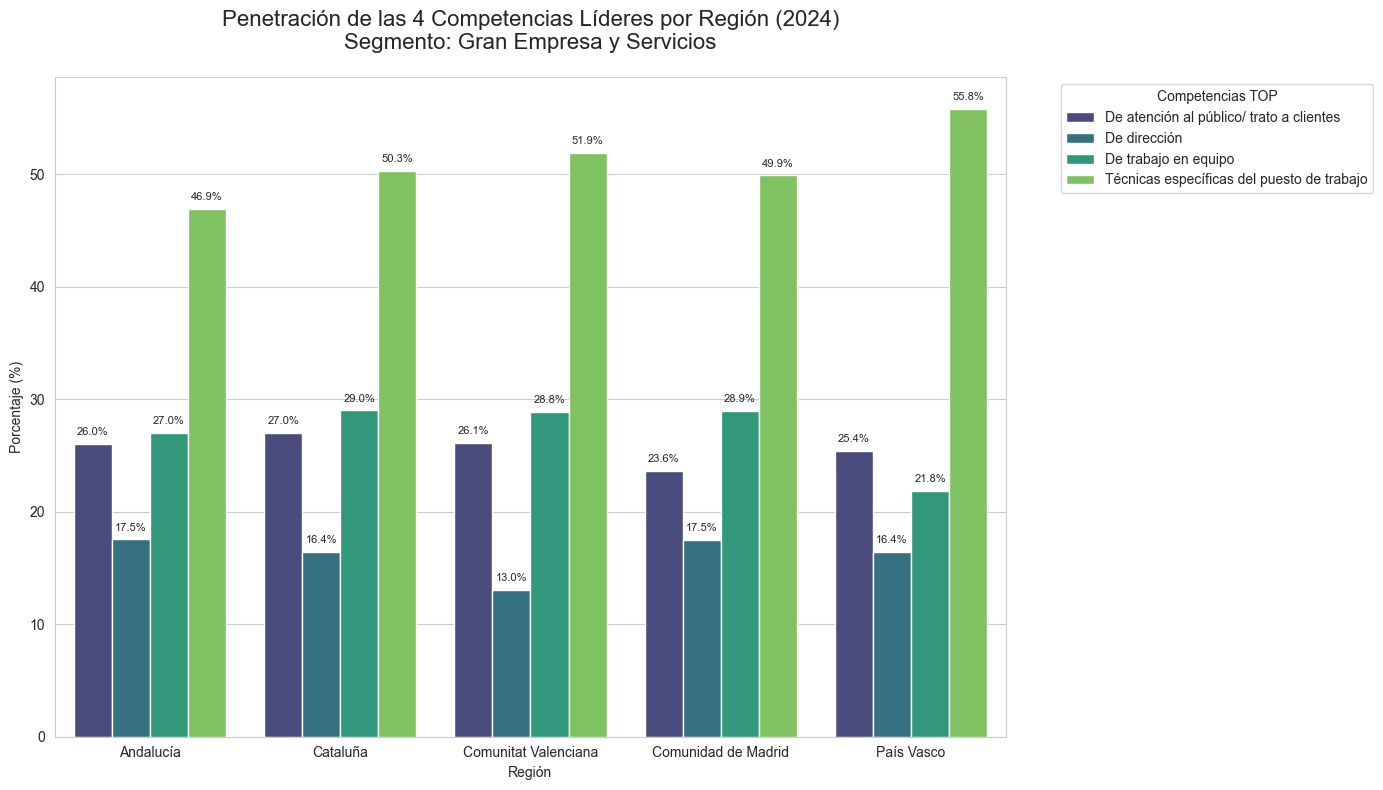

✅ Archivo 'top4_regional_segmentado_canva.csv' generado.


In [ ]:
#Definimos tus segmentos de interés
segmentos = [
    'Empresa de entre 250 y 499 trabajadores', 
    'Empresa de servicios', 
    'Andalucía', 'Cataluña', 'Comunitat Valenciana', 
    'Comunidad de Madrid', 'País Vasco'
]

#Preparamos datos de 2024 y calculamos la Media de Estudio para elegir el Top 4
df_2024 = df_competencias[df_competencias['Año'] == 2024].copy()

#Aseguramos que todo sea numérico
for col in segmentos:
    df_2024[col] = pd.to_numeric(df_2024[col], errors='coerce')

#Calculamos la media de los segmentos para cada competencia
df_2024['Media_Estudio'] = df_2024[segmentos].mean(axis=1)

# Seleccionamos las 4 con mayor media en tus segmentos
top_4_nombres = df_2024.sort_values('Media_Estudio', ascending=False).head(4)['Competencias'].tolist()

print(f"✅ Top 4 detectado para tus segmentos:\n{top_4_nombres}")

#Preparamos el gráfico Regional (Solo CCAA)
regiones = ['Andalucía', 'Cataluña', 'Comunitat Valenciana', 'Comunidad de Madrid', 'País Vasco']

df_plot_reg = df_2024[df_2024['Competencias'].isin(top_4_nombres)].melt(
    id_vars=['Competencias'], 
    value_vars=regiones,
    var_name='Región', value_name='Porcentaje'
)

# --- VISUALIZACIÓN EN PYTHON ---
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
ax = sns.barplot(data=df_plot_reg, x='Región', y='Porcentaje', hue='Competencias', palette='viridis')

plt.title('Penetración de las 4 Competencias Líderes por Región (2024)\nSegmento: Gran Empresa y Servicios', fontsize=16, pad=20)
plt.ylabel('Porcentaje (%)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Competencias TOP")

# Etiquetas de valor sobre las barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

# --- EXPORTACIÓN PARA CANVA ---
# Creamos la tabla "Ancha" (Regiones en filas, Competencias en columnas)
df_canva_reg = df_2024[df_2024['Competencias'].isin(top_4_nombres)].set_index('Competencias')[regiones].T

# Acortamos los nombres de las competencias para que el gráfico sea legible
df_canva_reg.columns = ['Técnicas Puesto', 'Trabajo Equipo', 'Atención Cliente', 'Dirección/Gestión'] # Ajusta según tu top 4 real

df_canva_reg.to_csv('top4_regional_segmentado_canva.csv', index_label='Region')
print("✅ Archivo 'top4_regional_segmentado_canva.csv' generado.")

**Segemento vs media nacional**

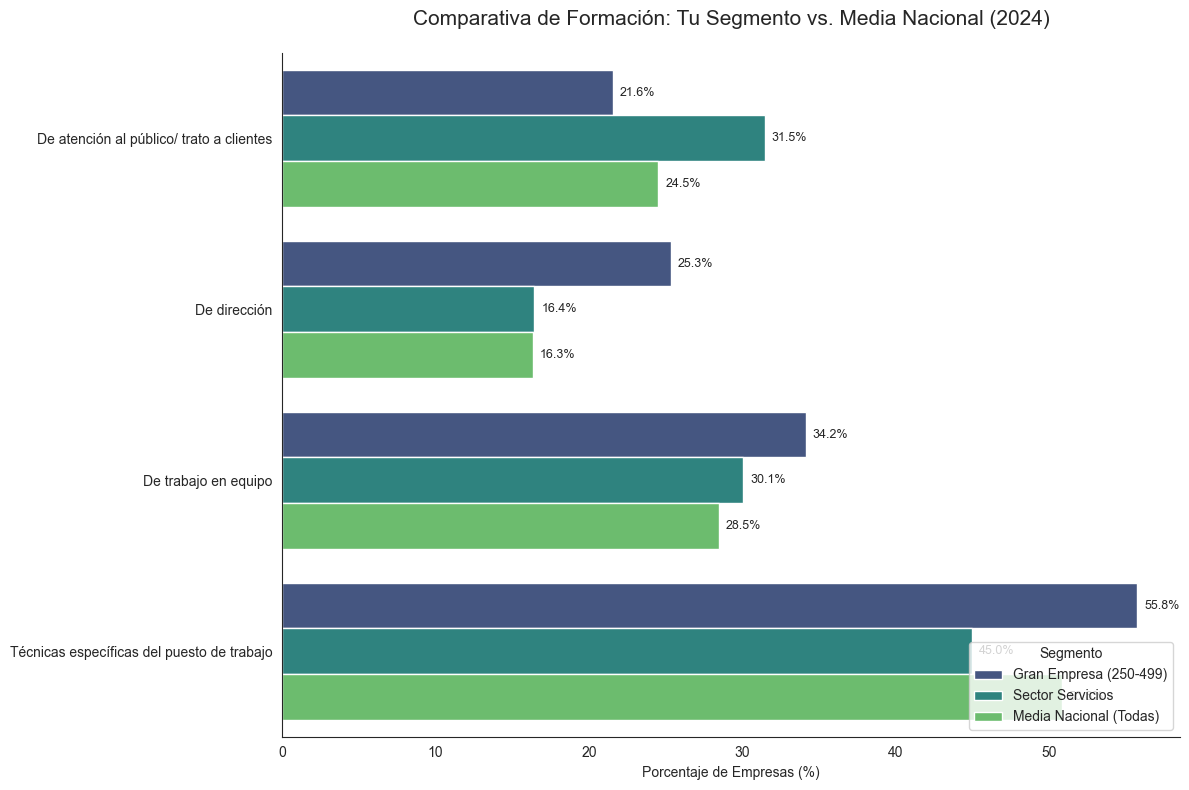

✅ Archivo 'comparativa_segmentos_final_canva.csv' generado correctamente.


In [ ]:


#Definimos los segmentos específicos y el total nacional
segmentos_comparar = ['Empresa de entre 250 y 499 trabajadores', 'Empresa de servicios', 'Total empresas (sin filtrar)']

#Preparamos datos de 2024
df_2024 = df_competencias[df_competencias['Año'] == 2024].copy()

# Aseguramos que las columnas sean números
for col in segmentos_comparar:
    df_2024[col] = pd.to_numeric(df_2024[col], errors='coerce')

#Elegimos el Top 4 basándonos en la media de Gran Empresa y Servicios
df_2024['Media_Referencia'] = df_2024[['Empresa de entre 250 y 499 trabajadores', 'Empresa de servicios']].mean(axis=1)
top_4_nombres = df_2024.sort_values('Media_Referencia', ascending=False).head(4)['Competencias'].tolist()

#Filtramos y preparamos los datos para el gráfico (Melt)
df_plot_seg = df_2024[df_2024['Competencias'].isin(top_4_nombres)].melt(
    id_vars=['Competencias'], 
    value_vars=segmentos_comparar,
    var_name='Segmento', value_name='Porcentaje'
)

# --- CORRECCIÓN DEL ERROR ---
# Renombramos los segmentos para que queden bonitos en el gráfico
df_plot_seg['Segmento'] = df_plot_seg['Segmento'].replace({
    'Empresa de entre 250 y 499 trabajadores': 'Gran Empresa (250-499)',
    'Empresa de servicios': 'Sector Servicios',
    'Total empresas (sin filtrar)': 'Media Nacional (Todas)'
})

# --- VISUALIZACIÓN EN PYTHON ---
plt.figure(figsize=(12, 8))
sns.set_style("white")
ax = sns.barplot(data=df_plot_seg, y='Competencias', x='Porcentaje', hue='Segmento', palette='viridis')

plt.title('Comparativa de Formación: Tu Segmento vs. Media Nacional (2024)', fontsize=15, pad=20)
plt.xlabel('Porcentaje de Empresas (%)')
plt.ylabel('')
plt.legend(title='Segmento', loc='lower right')

# Añadir etiquetas de valor
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', fontsize=9, xytext=(5, 0), textcoords='offset points')

sns.despine()
plt.tight_layout()
plt.show()

# --- EXPORTACIÓN PARA CANVA ---
df_canva_final = df_2024[df_2024['Competencias'].isin(top_4_nombres)].set_index('Competencias')[segmentos_comparar]
df_canva_final.columns = ['Gran Empresa', 'Servicios', 'Media Nacional']

df_canva_final.to_csv('comparativa_segmentos_final_canva.csv', index_label='Competencia')
print("✅ Archivo 'comparativa_segmentos_final_canva.csv' generado correctamente.")